# NHS A&E Attendance & Performance Analysis - March 2026

## Project Overview
This project was an exploratory data analysis of NHS A&E attendance, waiting times, and emergency admissions using data published by NHS England for March 2026. The analysis identifyies key performance trends and pressure points across NHS trusts in England.

**Author:** Kingsley Eboh  
**Dataset:** NHS England Monthly A&E Attendance - March 2026
**Tools:** Python, Pandas, Matplotlib, Seaborn
**Skills:** Data Cleaning, Exploratory Data Analysis (EDA), Statistical Summarisation, trend analysis, data visualisation

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv('/home/king/Desktop/nhs-data-analysis/March-2026-CSV-G49lw.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (200, 22)

First 5 rows:


,Period,Org Code,Parent Org,Org name,A&E attendances Type 1,A&E attendances Type 2,A&E attendances Other A&E Department,A&E attendances Booked Appointments Type 1,A&E attendances Booked Appointments Type 2,A&E attendances Booked Appointments Other Department,...,Attendances over 4hrs Other Department,Attendances over 4hrs Booked Appointments Type 1,Attendances over 4hrs Booked Appointments Type 2,Attendances over 4hrs Booked Appointments Other Department,Patients who have waited 4-12 hs from DTA to admission,Patients who have waited 12+ hrs from DTA to admission,Emergency admissions via A&E - Type 1,Emergency admissions via A&E - Type 2,Emergency admissions via A&E - Other A&E department,Other emergency admissions
0,MSitAE-MARCH-2026,AQN04,NHS ENGLAND SOUTH EAST,PHL LYMINGTON UTC,0,0,3090,0,0,32,...,30,0,0,0,0,0,0,0,0,0
1,MSitAE-MARCH-2026,C82009,NHS ENGLAND MIDLANDS,MARKET HARBOROUGH MED.CTR,0,0,243,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,MSitAE-MARCH-2026,DJV01,NHS ENGLAND SOUTH EAST,HERNE BAY HEALTH CARE LTD,0,0,2623,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,MSitAE-MARCH-2026,NDJ,NHS ENGLAND SOUTH EAST,FIRST COMMUNITY HEALTH AND CARE CIC,0,0,2366,0,0,0,...,25,0,0,0,0,0,0,0,0,0
4,MSitAE-MARCH-2026,NQT5F,NHS ENGLAND NORTH WEST,SKELMERSDALE WALK IN CENTRE,0,0,1696,0,0,0,...,16,0,0,0,0,0,0,0,0,0


## Data Quality Assessment 
Prior to analysis, a systematic data quality assessment was conducted to validate the integrity of the dataset. This included checking for missing values, duplicate records, and confirming appropriate data types across all columns, ensuring the dataset was fit for purpose before any analytical conclusions were drawn.

In [24]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Check for duplicates
print("\nDuplicate rows:", df.duplicated().sum())

# Check data types
print("\nData types:")
print(df.dtypes)

Missing values per column:
Period                                                        0
Org Code                                                      0
Parent Org                                                    0
Org name                                                      0
A&E attendances Type 1                                        0
A&E attendances Type 2                                        0
A&E attendances Other A&E Department                          0
A&E attendances Booked Appointments Type 1                    0
A&E attendances Booked Appointments Type 2                    0
A&E attendances Booked Appointments Other Department          0
Attendances over 4hrs Type 1                                  0
Attendances over 4hrs Type 2                                  0
Attendances over 4hrs Other Department                        0
Attendances over 4hrs Booked Appointments Type 1              0
Attendances over 4hrs Booked Appointments Type 2              0
Attendances o

In [25]:
# Drop fully empty rows
df = df.dropna(how='all')

# Check period column
print("Unique periods:")
print(df['Period'].unique())

print("\nCleaned shape:", df.shape)

Unique periods:
<StringArray>
['MSitAE-MARCH-2026', 'TOTAL']
Length: 2, dtype: str

Cleaned shape: (200, 22)


## Data Cleaning & Preparation

The dataset was filtered to organisation level records to ensure analysis reflected individual NHS trust performance. Column structures were reviewed and prepared for downstream analysis, including standardising naming conventions and isolating the relevant attendance, waiting time, and emergency admissions variables required for each analytical objective.

In [26]:
# Keep only trust level data, exclude the TOTAL row
df_trusts = df[df['Period'] == 'MSitAE-MARCH-2026'].copy()

# Reset index
df_trusts = df_trusts.reset_index(drop=True)

print("Number of trust:", len(df_trusts))
print("\nSample org names:")
print(df_trusts['Org name'].head(10))

Number of trust: 199

Sample org names:
0                                    PHL LYMINGTON UTC
1                            MARKET HARBOROUGH MED.CTR
2                            HERNE BAY HEALTH CARE LTD
3                  FIRST COMMUNITY HEALTH AND CARE CIC
4                          SKELMERSDALE WALK IN CENTRE
5                            PAULTON MEMORIAL HOSPITAL
6                       SUMMERFIELD URGENT CARE CENTRE
7                               ASHFORD WALK-IN-CENTRE
8                                WOKING WALK IN CENTRE
9    LIVERPOOL HEART AND CHEST HOSPITAL NHS FOUNDAT...
Name: Org name, dtype: str


## Analysis 1: Total A&E Attendances by Organisation 
This analysis identifies the NHS trusts recording the highest total A&E 
attendances in March 2026, aggregating across Type 1, Type 2, and Other A&E department categories. 

The bar chart below ranks the top 10 trusts by total attendance volume, 
highlighting the significant variation in demand across organisations and 
drawing attention to the trusts under the greatest operational pressure 
during this period.

In [27]:
# Calculate total attendances per organisation
df_trusts['Total Attendances'] = (
    df_trusts['A&E attendances Type 1'] +
    df_trusts['A&E attendances Type 2'] +
    df_trusts['A&E attendances Other A&E Department']
)

# Top 10 organisations by attendance
top10 = df_trusts[['Org name', 'Total Attendances']].sort_values(
                   'Total Attendances', ascending=False).head(10)

    

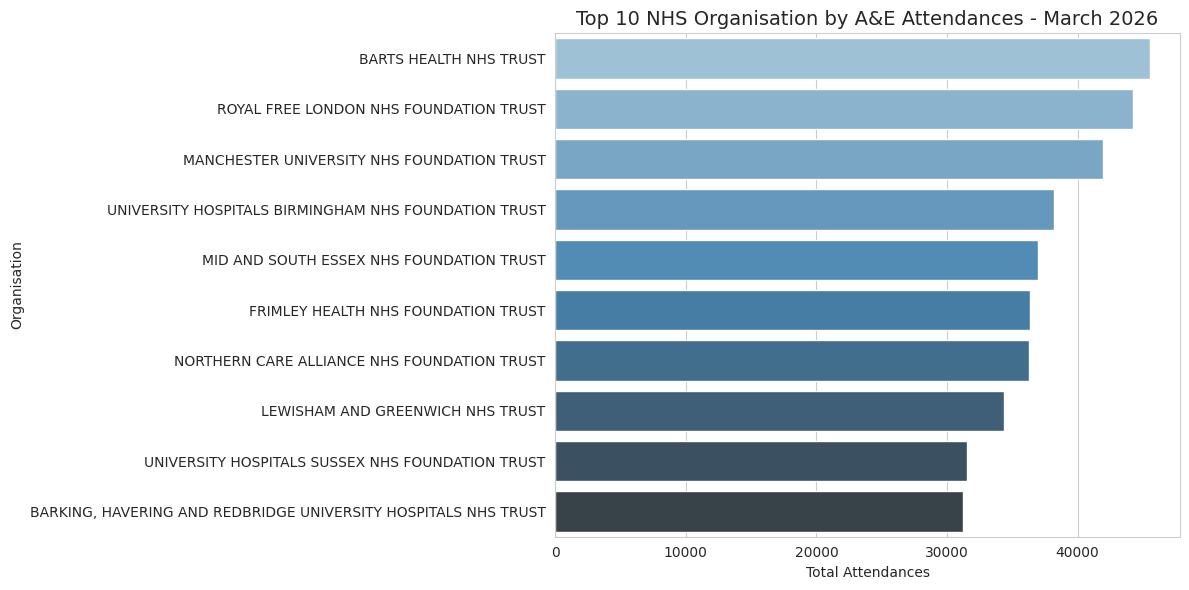

In [28]:
# Visualise top 10
plt.figure(figsize=(12, 6))
sns.barplot(data=top10, x='Total Attendances', y='Org name',
            hue='Org name', palette='Blues_d', legend=False)
plt.title('Top 10 NHS Organisation by A&E Attendances - March 2026', fontsize=14)
plt.xlabel('Total Attendances')
plt.ylabel('Organisation')
plt.tight_layout()
plt.savefig('top10_attendances.png')
plt.show()
          

## Analysis 2: 4-Hour Waiting Time Performance
This analysis examines organisational compliance with the NHS 4-hour waiting 
time standard, identifying the trusts recording the highest number of 
attendances breaching the target in March 2026. T

The bar chart below ranks the top 10 trusts by total 4-hour breaches across 
Type 1, Type 2, and Other A&E department categories, providing a clear 
picture of where waiting time pressures were most acute during this period.

In [29]:
# Calculate total attendances over 4 hours 
df_trusts['Total Over 4hrs'] = (
    df_trusts['Attendances over 4hrs Type 1'] +
    df_trusts['Attendances over 4hrs Type 2'] +
    df_trusts['Attendances over 4hrs Other Department']
)

# Calculate percentage over 4 hours 
df_trusts['% Over 4hrs'] = (
    df_trusts['Total Over 4hrs'] / df_trusts['Total Attendances'] * 100
).round(2)

# Top 10 worst performing organisations
worst10 = df_trusts[['Org name', 'Total Attendances', 'Total Over 4hrs', '% Over 4hrs']]\
    .sort_values('% Over 4hrs', ascending=False).head(10)

print(worst10)

                                              Org name  Total Attendances  \
71                             EAST CHESHIRE NHS TRUST               4365   
104      THE SHREWSBURY AND TELFORD HOSPITAL NHS TRUST              14083   
177             SURREY AND SUSSEX HEALTHCARE NHS TRUST              10583   
88   WIRRAL UNIVERSITY TEACHING HOSPITAL NHS FOUNDA...              11406   
72   COUNTESS OF CHESTER HOSPITAL NHS FOUNDATION TRUST               8089   
46         DORSET COUNTY HOSPITAL NHS FOUNDATION TRUST               4613   
163           HAMPSHIRE HOSPITALS NHS FOUNDATION TRUST              15212   
49   NORTH CUMBRIA INTEGRATED CARE NHS FOUNDATION T...              11161   
159   ROYAL UNITED HOSPITALS BATH NHS FOUNDATION TRUST               9444   
184        MID CHESHIRE HOSPITALS NHS FOUNDATION TRUST              10728   

     Total Over 4hrs  % Over 4hrs  
71              2215        50.74  
104             6651        47.23  
177             4778        45.15  
88      

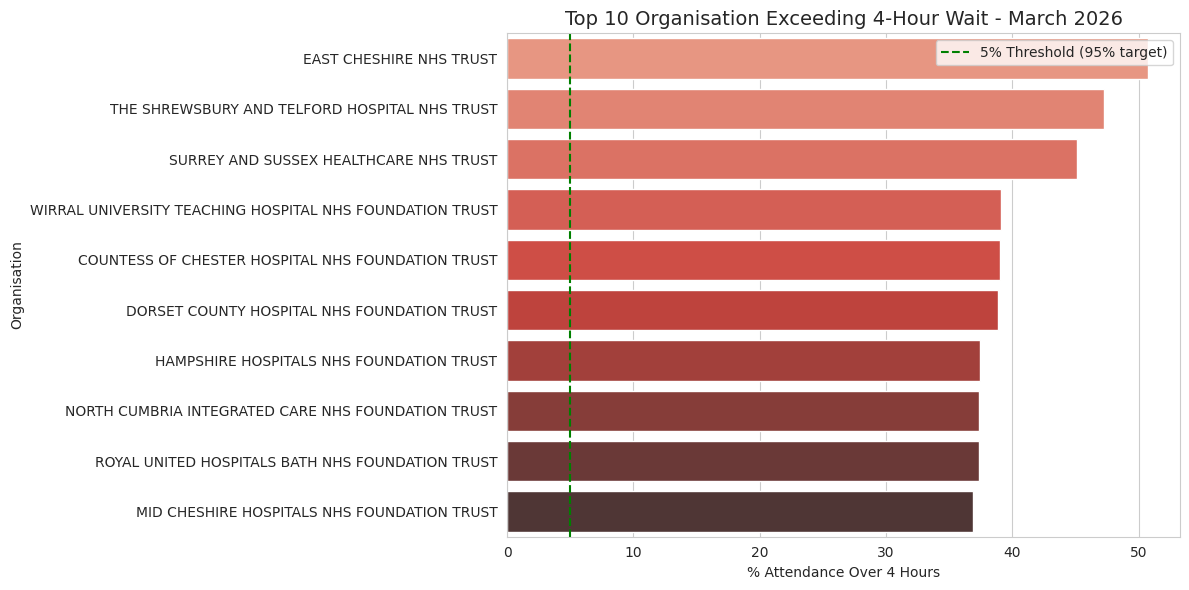

In [30]:
# Visualise worst 10
plt.figure(figsize=(12, 6))
sns.barplot(data=worst10, x='% Over 4hrs', y='Org name',
            hue='Org name', palette='Reds_d', legend=False)
plt.axvline(x=5, color='green', linestyle='--', label='5% Threshold (95% target)')
plt.title('Top 10 Organisation Exceeding 4-Hour Wait - March 2026', fontsize=14)
plt.xlabel('% Attendance Over 4 Hours')
plt.ylabel('Organisation')
plt.legend()
plt.tight_layout()
plt.savefig('worst10_4hr_performance.png')
plt.show()
          

# Analysis 3: Long Waiting Times
This analysis examines prolonged waiting times following a Decision to Admit 
(DTA), identifying the NHS trusts with the highest number of patients 
experiencing extended delays before receiving an inpatient bed. Two waiting 
time thresholds are assessed: patients waiting between 4 and 12 hours, and 
those waiting 12 hours or more. The latter representing a significant 
breach of acceptable care standards and a key indicator of wider system 
pressure.

The charts below rank the top 10 trusts across both thresholds, enabling 
a comparative view of where post-admission delays were most severe in 
March 2026.

In [31]:
# Sort by 12+ hour waits
long_waits = df_trusts[['Org name',
                        'Patients who have waited 4-12 hs from DTA to admission', 
                        'Patients who have waited 12+ hrs from DTA to admission']]\
    .sort_values('Patients who have waited 12+ hrs from DTA to admission', ascending=False).head(10)

print(long_waits)

                                              Org name  \
157             ROYAL FREE LONDON NHS FOUNDATION TRUST   
99   UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...   
182                             BARTS HEALTH NHS TRUST   
78           NOTTINGHAM UNIVERSITY HOSPITALS NHS TRUST   
104      THE SHREWSBURY AND TELFORD HOSPITAL NHS TRUST   
119   UNITED LINCOLNSHIRE TEACHING HOSPITALS NHS TRUST   
145  LIVERPOOL UNIVERSITY HOSPITALS NHS FOUNDATION ...   
162        NORTHERN CARE ALLIANCE NHS FOUNDATION TRUST   
126  EAST KENT HOSPITALS UNIVERSITY NHS FOUNDATION ...   
54    UNIVERSITY HOSPITALS SUSSEX NHS FOUNDATION TRUST   

     Patients who have waited 4-12 hs from DTA to admission  \
157                                                912        
99                                                2883        
182                                               1010        
78                                                 114        
104                                           

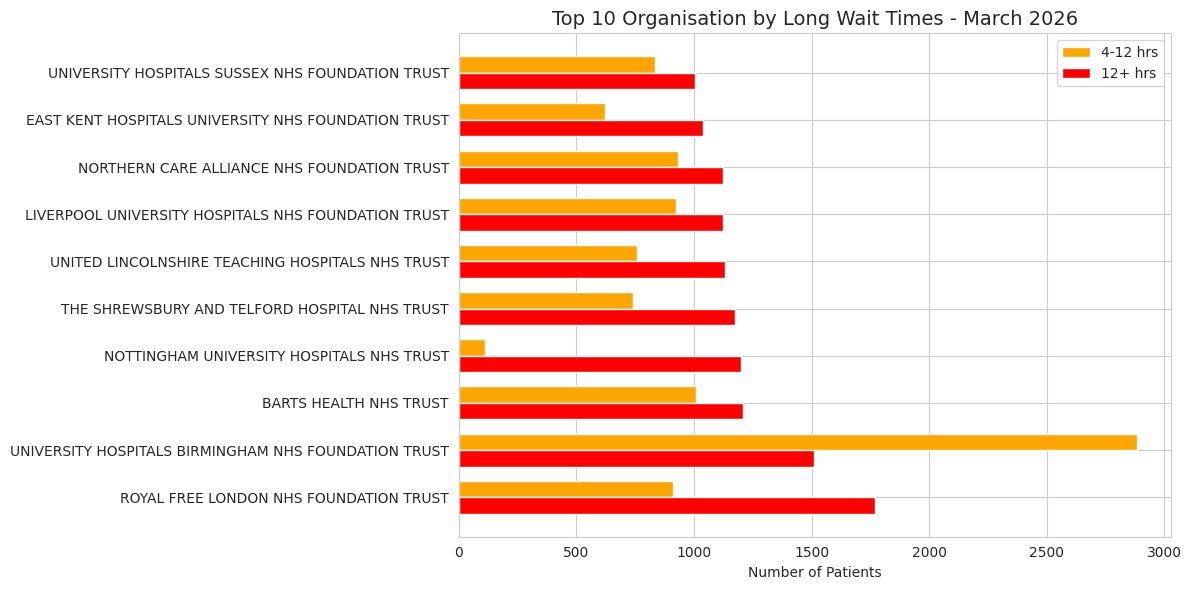

In [32]:
# Visualise long waits
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(long_waits))
width = 0.35

ax.barh([i + width/2 for i in x],
    long_waits['Patients who have waited 4-12 hs from DTA to admission'],
    width, label='4-12 hrs', color='orange')

ax.barh([i - width/2 for i in x],
    long_waits['Patients who have waited 12+ hrs from DTA to admission'],
    width, label='12+ hrs', color='red')

ax.set_yticks(list(x))
ax.set_yticklabels(long_waits['Org name'])
ax.set_xlabel('Number of Patients')
ax.set_title('Top 10 Organisation by Long Wait Times - March 2026', fontsize=14)
ax.legend()
plt.tight_layout()
plt.savefig('long_waits.png')
plt.show()

In [33]:
print(df_trusts['Patients who have waited 4-12 hs from DTA to admission'].head()) 
print(df_trusts['Patients who have waited 12+ hrs from DTA to admission'].head()) 

0    0
1    0
2    0
3    0
4    0
Name: Patients who have waited 4-12 hs from DTA to admission, dtype: int64
0    0
1    0
2    0
3    0
4    0
Name: Patients who have waited 12+ hrs from DTA to admission, dtype: int64


In [34]:
print(df_trusts.shape) 
print(df_trusts.head(2)) 

(199, 25)
              Period Org Code               Parent Org  \
0  MSitAE-MARCH-2026    AQN04  NHS ENGLAND SOUTH EAST    
1  MSitAE-MARCH-2026   C82009    NHS ENGLAND MIDLANDS    

                    Org name  A&E attendances Type 1  A&E attendances Type 2  \
0          PHL LYMINGTON UTC                       0                       0   
1  MARKET HARBOROUGH MED.CTR                       0                       0   

   A&E attendances Other A&E Department  \
0                                  3090   
1                                   243   

   A&E attendances Booked Appointments Type 1  \
0                                           0   
1                                           0   

   A&E attendances Booked Appointments Type 2  \
0                                           0   
1                                           0   

   A&E attendances Booked Appointments Other Department  ...  \
0                                                 32     ...   
1                   

# ANALYSIS 4: Emergency Admissions via A&E

This analysis examines emergency admissions processed through A&E departments 
across NHS trusts in March 2026, aggregating across Type 1, 
Type 2, and Other A&E department categories. In addition 
to admission volumes, an emergency admission rate is calculated as a 
proportion of total A&E attendances, providing a normalised measure that 
enables fair comparison across trusts of varying sizes.

The charts below rank the top 10 trusts by total emergency admission volume 
and by emergency admission rate, distinguishing between trusts that are 
large by scale and those where emergency admissions represent a 
disproportionately high share of their overall activity.

In [35]:
# Calculate total emergency admissions per org 
df['Total Emergency Admissions'] = (
    df['Emergency admissions via A&E - Type 1'] +
    df['Emergency admissions via A&E - Type 2'] +
    df['Emergency admissions via A&E - Other A&E department']
)

# Calculate total A&E attendances (reuse or recalculate)
df['Total Attendances'] = (
    df['A&E attendances Type 1'] +
    df['A&E attendances Type 2'] +
    df['A&E attendances Other A&E Department']
)

# Replace 0 attendances with NaN to avoid division errors
df['Total Attendances'] = df['Total Attendances'].replace(0, float('nan'))

# Admission rate: emergency admissions as % of total attendances 
df['Emergency Admission Rate (%)'] = (
    df['Total Emergency Admissions'] / df['Total Attendances'] * 100
).round(2)

# Drop rows where key columns are NaN for clean charting
df_clean = df.dropna(subset=['Total Emergency Admissions', 'Total Attendances', 'Emergency Admission Rate (%)'])

In [36]:
# Top 10 orgs by total emergency admissions
top10_admissions = (
    df_clean[['Org name', 'Total Emergency Admissions', 'Emergency Admission Rate (%)']]
    .sort_values('Total Emergency Admissions', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top10_admissions.index += 1

print("Top 10 Organisations by Emergency Admissions (March 2026)")
print("=" * 60)
print(top10_admissions.to_string())

Top 10 Organisations by Emergency Admissions (March 2026)
                                                   Org name  Total Emergency Admissions  Emergency Admission Rate (%)
1                                                     TOTAL                      410005                         17.44
2      UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION TRUST                       10755                         28.13
3                  MID AND SOUTH ESSEX NHS FOUNDATION TRUST                        9033                         24.46
4          UNIVERSITY HOSPITALS SUSSEX NHS FOUNDATION TRUST                        8884                         28.20
5               NORTHERN CARE ALLIANCE NHS FOUNDATION TRUST                        8331                         22.94
6   MERSEY AND WEST LANCASHIRE TEACHING HOSPITALS NHS TRUST                        8027                         31.53
7               UNIVERSITY HOSPITALS OF LEICESTER NHS TRUST                        7244                         28.3

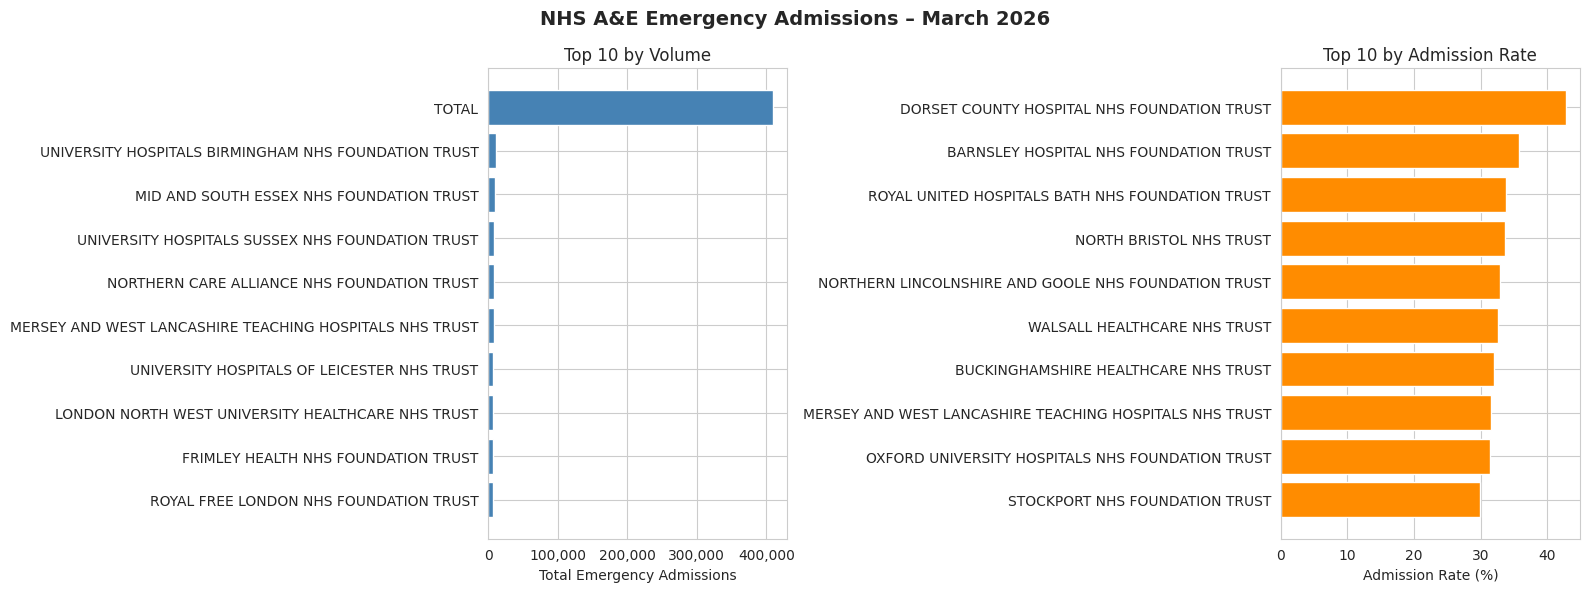

Chart saved.


In [37]:
# Bar chart: Top 10 emergency admissions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('NHS A&E Emergency Admissions – March 2026', fontsize=14, fontweight='bold')

# Right: Admission rate (all orgs, sorted)
top10_rate = (
    df_clean[['Org name', 'Emergency Admission Rate (%)']]
    .sort_values('Emergency Admission Rate (%)', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

# Left: Total admissions
axes[0].barh(
    top10_admissions['Org name'][::-1],
    top10_admissions['Total Emergency Admissions'][::-1],
    color='steelblue', edgecolor='white'
)
axes[0].set_xlabel('Total Emergency Admissions')
axes[0].set_title('Top 10 by Volume')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

axes[1].barh(
    top10_rate['Org name'][::-1],
    top10_rate['Emergency Admission Rate (%)'][::-1],
    color='darkorange', edgecolor='white'
)
axes[1].set_xlabel('Admission Rate (%)')
axes[1].set_title('Top 10 by Admission Rate')

plt.tight_layout()
plt.savefig('analysis4_emergency_admissions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

In [38]:
# National summary
national_admissions = df['Total Emergency Admissions'].sum()
national_attendances = df['Total Attendances'].sum()
national_rate = round(national_admissions / national_attendances * 100, 2)

print(f"\nNational Total Emergency Admissions : {national_admissions:,}")
print(f"National Total A&E Attendances      : {national_attendances:,}")
print(f"National Emergency Admission Rate   : {national_rate}%")


National Total Emergency Admissions : 820,010
National Total A&E Attendances      : 4,702,634.0
National Emergency Admission Rate   : 17.44%


# ANALYSIS 5: KEY FINDINGS SUMMARY

This section consolidates the findings from Analyses 1 through 4, presenting 
a national-level summary of NHS A&E performance for March 2026. Key metrics 
are aggregated across all organisations to provide a holistic picture of 
attendance volumes, 4-hour waiting time compliance, long wait pressures, 
and emergency admission activity across England.

The summary scorecard and visualisations below draw together the most 
significant trends and outliers identified throughout this analysis, 
contextualising individual trust performance against national totals and 
highlighting the organisations that emerged consistently across multiple 
performance indicators as facing the greatest operational demand during 
this period.

In [42]:
# Attendances
total_att = df['Total Attendances'].sum()
total_type1 = df['A&E attendances Type 1'].sum()

# 4-hour performance (Type 1 only — standard NHS measure)
total_breaches_t1 = df['Attendances over 4hrs Type 1'].sum()
perf_4hr_t1 = round((1 - total_breaches_t1 / total_type1) * 100, 1)

# Long waits
total_4_12hr = df['Patients who have waited 4-12 hs from DTA to admission'].sum()
total_12hr_plus = df['Patients who have waited 12+ hrs from DTA to admission'].sum()
total_long_waits = total_4_12hr + total_12hr_plus

# Emergency admissions
total_emerg = df['Total Emergency Admissions'].sum()
emerg_rate = round(total_emerg / total_att * 100, 2)

# Top performers
best_4hr_org = (
    df.assign(Perf=lambda x: (1 - x['Attendances over 4hrs Type 1'] / x['A&E attendances Type 1']) * 100)
    .sort_values('Perf', ascending=False)
    .iloc[0]['Org name']
)
highest_admissions_org = df.sort_values('Total Emergency Admissions', ascending=False).iloc[0]['Org name']
most_12hr_org = df.sort_values('Patients who have waited 12+ hrs from DTA to admission', ascending=False).iloc[0]['Org name']

In [43]:
# Print Summary
print("=" * 65)
print("       NHS A&E DATA ANALYSIS — KEY FINDINGS (March 2026)")
print("=" * 65)

print(f"""
ATTENDANCE
  Total A&E attendances (all types)  : {total_att:,}
  Type 1 (Major A&E) attendances     : {total_type1:,}

4-HOUR PERFORMANCE (Type 1)
  National 4-hour performance        : {perf_4hr_t1}%
  (NHS England standard target: 95%)
  Best performing organisation       : {best_4hr_org}

LONG WAITS (DTA to Admission)
  Patients waiting 4–12 hrs          : {total_4_12hr:,}
  Patients waiting 12+ hrs           : {total_12hr_plus:,}
  Total long-wait patients           : {total_long_waits:,}
  Highest 12hr+ waits organisation   : {most_12hr_org}

EMERGENCY ADMISSIONS
  Total emergency admissions via A&E : {total_emerg:,}
  National admission rate            : {emerg_rate}%
  Highest admissions organisation    : {highest_admissions_org}
""")
print("=" * 65)

       NHS A&E DATA ANALYSIS — KEY FINDINGS (March 2026)

ATTENDANCE
  Total A&E attendances (all types)  : 4,702,634.0
  Type 1 (Major A&E) attendances     : 2,901,960

4-HOUR PERFORMANCE (Type 1)
  National 4-hour performance        : 63.9%
  (NHS England standard target: 95%)
  Best performing organisation       : SHEFFIELD CHILDREN'S NHS FOUNDATION TRUST

LONG WAITS (DTA to Admission)
  Patients waiting 4–12 hrs          : 154,410
  Patients waiting 12+ hrs           : 93,330
  Total long-wait patients           : 247,740
  Highest 12hr+ waits organisation   : TOTAL

EMERGENCY ADMISSIONS
  Total emergency admissions via A&E : 820,010
  National admission rate            : 17.44%
  Highest admissions organisation    : TOTAL



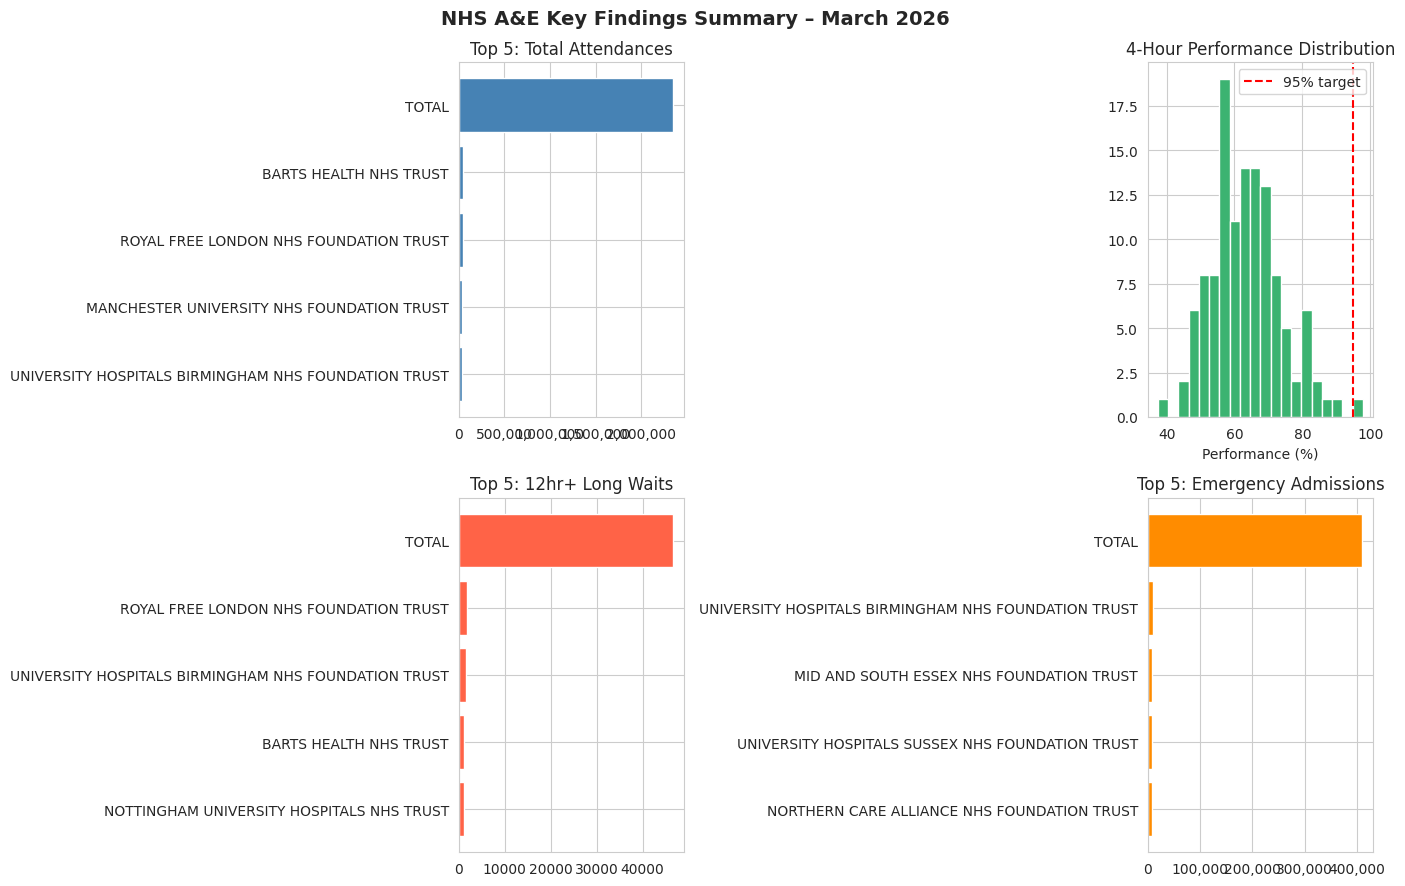

Summary chart saved.


In [44]:
# Summary bar chart (4 KPIs as visual scorecard)
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('NHS A&E Key Findings Summary – March 2026', fontsize=14, fontweight='bold')

# Panel 1: Top 5 orgs by total attendances
top5_att = df.nlargest(5, 'Total Attendances')[['Org name', 'Total Attendances']]
axes[0, 0].barh(top5_att['Org name'][::-1], top5_att['Total Attendances'][::-1], color='steelblue')
axes[0, 0].set_title('Top 5: Total Attendances')
axes[0, 0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Panel 2: 4-hr performance distribution (histogram)
df_valid = df[df['A&E attendances Type 1'] > 0].copy()
df_valid['4hr_perf'] = (1 - df_valid['Attendances over 4hrs Type 1'] / df_valid['A&E attendances Type 1']) * 100
axes[0, 1].hist(df_valid['4hr_perf'].dropna(), bins=20, color='mediumseagreen', edgecolor='white')
axes[0, 1].axvline(95, color='red', linestyle='--', label='95% target')
axes[0, 1].set_title('4-Hour Performance Distribution')
axes[0, 1].set_xlabel('Performance (%)')
axes[0, 1].legend()

# Panel 3: Top 5 orgs by 12hr+ waits
top5_12hr = df.nlargest(5, 'Patients who have waited 12+ hrs from DTA to admission')[
    ['Org name', 'Patients who have waited 12+ hrs from DTA to admission']
]
axes[1, 0].barh(top5_12hr['Org name'][::-1],
                top5_12hr['Patients who have waited 12+ hrs from DTA to admission'][::-1],
                color='tomato')
axes[1, 0].set_title('Top 5: 12hr+ Long Waits')

# Panel 4: Top 5 orgs by emergency admissions
top5_emerg = df.nlargest(5, 'Total Emergency Admissions')[['Org name', 'Total Emergency Admissions']]
axes[1, 1].barh(top5_emerg['Org name'][::-1], top5_emerg['Total Emergency Admissions'][::-1], color='darkorange')
axes[1, 1].set_title('Top 5: Emergency Admissions')
axes[1, 1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('analysis5_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Summary chart saved.")